In [1]:
import numpy as np 
import pandas as pd 
from collections import Counter
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import ast  # For safely converting string representations of lists
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_auc_score
from collections import Counter
from statsmodels.stats.inter_rater import fleiss_kappa
from sklearn.metrics import cohen_kappa_score
!pip install krippendorff
import krippendorff

import statsmodels.api as sm
import statsmodels.formula.api as smf
!pip install pingouin
import pingouin as pg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 6.7 MB/s eta 0:00:00


In [2]:
df = pd.read_csv("/kaggle/input/final-data/emi_survey.csv")

In [3]:
df.keys()

Index(['id', 'evidence survey', 'intuition survey', 'N', 'original_text',
       'text', 'emi_bin', 'intuition_bin', 'evidence_bin', 'decade', 'year',
       'begin', 'end', 'date', 'session', 'electoralTerm', 'firstName',
       'lastName', 'politicianId', 'factionId', 'documentUrl', 'positionShort',
       'positionLong', 'length', 'chunk_length', 'evidence_score',
       'intuition_score', 'chunk_length_bin', 'evidence_mean', 'evidence_adj',
       'intuition_mean', 'intuition_adj', 'evidence_z', 'intuition_z', 'emi'],
      dtype='object')

In [4]:
df = df.dropna(subset=["emi"])

df["evidence survey"] = df["evidence survey"].apply(lambda x: eval(x) if isinstance(x, str) else x)

df["intuition survey"] = df["intuition survey"].apply(lambda x: eval(x) if isinstance(x, str) else x)

In [5]:
type(df["intuition survey"].iloc[0])

list

In [6]:
df

,id,evidence survey,intuition survey,N,original_text,text,emi_bin,intuition_bin,evidence_bin,decade,...,evidence_score,intuition_score,chunk_length_bin,evidence_mean,evidence_adj,intuition_mean,intuition_adj,evidence_z,intuition_z,emi
1,10001,"[1.0, -2.0, -2.0, 2.0, 2.0]","[-1.0, 2.0, 2.0, 2.0, -2.0]",5,"Ich lehne es ab, mich in diesem Hohen Hause au...",lehne Hohen Hause Niveau begeben Kabarett übli...,"(-5.186191999999999, -2.1966578749999996]","(0.46014310000000025, 2.6364639000000003]","(-1.70590185, 1.1031212999999997]",1950.0,...,-0.023104,0.226178,"(40, 50]",0.044534,-0.067638,0.018643,0.207535,-0.707661,1.780287,-2.487948
2,1004280,"[1.0, 1.0, 1.0, 1.0, -1.0]","[-1.0, 0.0, 2.0, 2.0, 2.0]",5,"Frau Kollegin, vielen Dank, dass Sie noch einm...",Kollegin vielen Dank darauf hinweisen deutlich...,"(0.79287625, 3.7824103750000004]","(0.46014310000000025, 2.6364639000000003]","(1.1031212999999997, 3.9121444499999996]",2010.0,...,0.198081,0.115429,"(30, 40]",-0.009948,0.208029,-0.011461,0.126891,2.176502,1.088502,1.088000
3,1005062,"[1.0, -2.0, -1.0, 2.0, -2.0]","[-2.0, 2.0, 1.0, 1.0, 2.0]",5,"Vielen Dank, Frau Kollegin, dass ich diese Zwi...",Vielen Dank Kollegin Zwischenfrage stellen dar...,"(0.79287625, 3.7824103750000004]","(0.46014310000000025, 2.6364639000000003]","(3.9121444499999996, 6.721167599999999]",2010.0,...,0.476700,0.180839,"(20, 30]",-0.031679,0.508379,-0.020281,0.201120,5.318909,1.725261,3.593648
4,1006590,"[1.0, -2.0, -1.0, -1.0, -2.0]","[2.0, 2.0, 1.0, 1.0, 2.0]",5,Da die Staatsanwaltschaften und Gerichte diese...,Staatsanwaltschaften Gerichte Schlussfolgerung...,"(-2.1966578749999996, 0.79287625]","(0.46014310000000025, 2.6364639000000003]","(-1.70590185, 1.1031212999999997]",2010.0,...,0.107220,0.253291,"(40, 50]",0.044534,0.062686,0.018643,0.234648,0.655849,2.012872,-1.357023
5,1007107,"[0.0, -1.0, -1.0, -2.0, 1.0]","[1.0, 2.0, 2.0, 2.0, 0.0]",5,"Meine Damen und Herren, ich komme zum Ende. Ic...",komme Ende Bitte eigene Fraktion Lasst hervorr...,"(-2.1966578749999996, 0.79287625]","(0.46014310000000025, 2.6364639000000003]","(1.1031212999999997, 3.9121444499999996]",2010.0,...,0.115150,0.240723,"(20, 30]",-0.031679,0.146829,-0.020281,0.261004,1.536199,2.238965,-0.702766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139,97649,"[1.0, 1.0, -1.0, -1.0, 1.0]","[-1.0, 2.0, 1.0, 1.0, 0.0]",5,"Herr Staatssekretär, darf ich aus Ihrer ersten...",Staatssekretär darf ersten Antwort entnehmen B...,"(0.79287625, 3.7824103750000004]","(-1.7161776999999998, 0.46014310000000025]","(1.1031212999999997, 3.9121444499999996]",1960.0,...,0.102119,0.020398,"(30, 40]",-0.009948,0.112067,-0.011461,0.031859,1.172504,0.273296,0.899208
1140,97876,"[0.0, 1.0, 2.0, 0.0, 2.0]","[1.0, -2.0, -2.0, 0.0, 2.0]",5,"Herr Kollege Lohmar, würden Sie nicht doch an ...",Kollege Lohmar Hand zitierten Texte Verwaltung...,"(3.7824103750000004, 6.7719445]","(-1.7161776999999998, 0.46014310000000025]","(3.9121444499999996, 6.721167599999999]",1960.0,...,0.350174,-0.065635,"(20, 30]",-0.031679,0.381853,-0.020281,-0.045353,3.995134,-0.389053,4.384187
1141,9796,"[-2.0, 1.0, -1.0, 1.0, 1.0, -2.0, 1.0, -1.0, 1...","[2.0, -1.0, 1.0, 0.0, 1.0, 2.0, -1.0, 1.0, 0.0...",10,"Es gibt für Ihre Auffassung, Herr Mommer, nur ...",gibt Auffassung Mommer Erklärung nämlich Mitgl...,"(-2.1966578749999996, 0.79287625]","(2.6364639000000003, 4.8127847]","(1.1031212999999997, 3.9121444499999996]",1950.0,...,0.161373,0.357907,"(30, 40]",-0.009948,0.171321,-0.011461,0.369368,1.792441,3.168539,-1.376097
1142,98182,"[0.0, -1.0, 0.0, 2.0, 2.0, 0.0, -1.0, 0.0, 2.0...","[0.0, 1.0, 0.0, 0.0, -2.0, 0.0, 1.0, 0.0, 0.0,...",10,"Herr Dr. Czaja, darf ich Sie bitten, dann auch...",Czaja darf bitten Abs interpretieren heißt Min...,"(0.79287625, 3.7824103750000004]","(-1.7161776999999998, 0.46014310000000025]","(-1.70590185, 1.1031212999999997]",1960.0,...,0.020748,-0.185367,"(10, 20]",-0.031656,0.052404,-0.016343,-0.169024,0.548281,-1.449933,1.99

In [7]:
# Function to calculate user agreement as the most common value's proportion
def user_agreement(lst):
    lst = eval(lst) if isinstance(lst, str) else lst  # Convert string to list if necessary
    if not lst:
        return None
    counter = Counter(lst)
    most_common_count = counter.most_common(1)[0][1]
    return most_common_count / len(lst)


# Transform values to binary labels (1 for positive, 0 otherwise)
def transform_labels_binary(lst):
    lst = eval(lst) if isinstance(lst, str) else lst  # Convert string to list if necessary
    if not lst:
        return []
    return [1 if x in [1, 2] else 0 for x in lst]


# Determine the most frequent label for each row
def most_frequent_label_binary(lst):
    if not lst:
        return None
    counter = Counter(lst)
    return counter.most_common(1)[0][0]

### Aggregate Labels into numeric and binary numeric Labels

In [8]:
# Apply the function to calculate initial user agreement
df["evidence_agreement"] = df["evidence survey"].apply(user_agreement)
df["intuition_agreement"] = df["intuition survey"].apply(user_agreement)

df["evidence_transformed"] = df["evidence survey"].apply(transform_labels_binary)
df["intuition_transformed"] = df["intuition survey"].apply(transform_labels_binary)

# Recalculate user agreement after transformation
df["evidence_agreement_transformed"] = df["evidence_transformed"].apply(user_agreement)
df["intuition_agreement_transformed"] = df["intuition_transformed"].apply(user_agreement)


import numpy as np

df["human_evidence_label"] = df["evidence_transformed"].apply(lambda x: 1 if np.sum(x) > len(x) / 2 else 0)
df["human_intuition_label"] = df["intuition_transformed"].apply(lambda x: 1 if np.sum(x) > len(x) / 2 else 0)


In [9]:
df

,id,evidence survey,intuition survey,N,original_text,text,emi_bin,intuition_bin,evidence_bin,decade,...,intuition_z,emi,evidence_agreement,intuition_agreement,evidence_transformed,intuition_transformed,evidence_agreement_transformed,intuition_agreement_transformed,human_evidence_label,human_intuition_label
1,10001,"[1.0, -2.0, -2.0, 2.0, 2.0]","[-1.0, 2.0, 2.0, 2.0, -2.0]",5,"Ich lehne es ab, mich in diesem Hohen Hause au...",lehne Hohen Hause Niveau begeben Kabarett übli...,"(-5.186191999999999, -2.1966578749999996]","(0.46014310000000025, 2.6364639000000003]","(-1.70590185, 1.1031212999999997]",1950.0,...,1.780287,-2.487948,0.4,0.6,"[1, 0, 0, 1, 1]","[0, 1, 1, 1, 0]",0.6,0.60,1,1
2,1004280,"[1.0, 1.0, 1.0, 1.0, -1.0]","[-1.0, 0.0, 2.0, 2.0, 2.0]",5,"Frau Kollegin, vielen Dank, dass Sie noch einm...",Kollegin vielen Dank darauf hinweisen deutlich...,"(0.79287625, 3.7824103750000004]","(0.46014310000000025, 2.6364639000000003]","(1.1031212999999997, 3.9121444499999996]",2010.0,...,1.088502,1.088000,0.8,0.6,"[1, 1, 1, 1, 0]","[0, 0, 1, 1, 1]",0.8,0.60,1,1
3,1005062,"[1.0, -2.0, -1.0, 2.0, -2.0]","[-2.0, 2.0, 1.0, 1.0, 2.0]",5,"Vielen Dank, Frau Kollegin, dass ich diese Zwi...",Vielen Dank Kollegin Zwischenfrage stellen dar...,"(0.79287625, 3.7824103750000004]","(0.46014310000000025, 2.6364639000000003]","(3.9121444499999996, 6.721167599999999]",2010.0,...,1.725261,3.593648,0.4,0.4,"[1, 0, 0, 1, 0]","[0, 1, 1, 1, 1]",0.6,0.80,0,1
4,1006590,"[1.0, -2.0, -1.0, -1.0, -2.0]","[2.0, 2.0, 1.0, 1.0, 2.0]",5,Da die Staatsanwaltschaften und Gerichte diese...,Staatsanwaltschaften Gerichte Schlussfolgerung...,"(-2.1966578749999996, 0.79287625]","(0.46014310000000025, 2.6364639000000003]","(-1.70590185, 1.1031212999999997]",2010.0,...,2.012872,-1.357023,0.4,0.6,"[1, 0, 0, 0, 0]","[1, 1, 1, 1, 1]",0.8,1.00,0,1
5,1007107,"[0.0, -1.0, -1.0, -2.0, 1.0]","[1.0, 2.0, 2.0, 2.0, 0.0]",5,"Meine Damen und Herren, ich komme zum Ende. Ic...",komme Ende Bitte eigene Fraktion Lasst hervorr...,"(-2.1966578749999996, 0.79287625]","(0.46014310000000025, 2.6364639000000003]","(1.1031212999999997, 3.9121444499999996]",2010.0,...,2.238965,-0.702766,0.4,0.6,"[0, 0, 0, 0, 1]","[1, 1, 1, 1, 0]",0.8,0.80,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139,97649,"[1.0, 1.0, -1.0, -1.0, 1.0]","[-1.0, 2.0, 1.0, 1.0, 0.0]",5,"Herr Staatssekretär, darf ich aus Ihrer ersten...",Staatssekretär darf ersten Antwort entnehmen B...,"(0.79287625, 3.7824103750000004]","(-1.7161776999999998, 0.46014310000000025]","(1.1031212999999997, 3.9121444499999996]",1960.0,...,0.273296,0.899208,0.6,0.4,"[1, 1, 0, 0, 1]","[0, 1, 1, 1, 0]",0.6,0.60,1,1
1140,97876,"[0.0, 1.0, 2.0, 0.0, 2.0]","[1.0, -2.0, -2.0, 0.0, 2.0]",5,"Herr Kollege Lohmar, würden Sie nicht doch an ...",Kollege Lohmar Hand zitierten Texte Verwaltung...,"(3.7824103750000004, 6.7719445]","(-1.7161776999999998, 0.46014310000000025]","(3.9121444499999996, 6.721167599999999]",1960.0,...,-0.389053,4.384187,0.4,0.4,"[0, 1, 1, 0, 1]","[1, 0, 0, 0, 1]",0.6,0.60,1,0
1141,9796,"[-2.0, 1.0, -1.0, 1.0, 1.0, -2.0, 1.0, -1.0, 1...","[2.0, -1.0, 1.0, 0.0, 1.0, 2.0, -1.0, 1.0, 0.0...",10,"Es gibt für Ihre Auffassung, Herr Mommer, nur ...",gibt Auffassung Mommer Erklärung nämlich Mitgl...,"(-2.1966578749999996, 0.79287625]","(2.6364639000000003, 4.8127847]","(1.1031212999999997, 3.9121444499999996]",1950.0,...,3.168539,-1.376097,0.6,0.4,"[0, 1, 0, 1, 1, 0, 1, 0, 1, 1]","[1, 0, 1, 0, 1, 1, 0, 1, 0, 1]",0.6,0.60,1,1
1142,98182,"[0.0, -1.0, 0.0, 2.0, 2.0, 0.0, -1.0, 0.0, 2.0...","[0.0, 1.0, 0.0, 0.0, -2.0, 0.0, 1.0, 0.0, 0.0,...",10,"Herr Dr. Czaja, darf ich Sie bitten, dann auch...",Czaja darf bitten Abs interpretieren heißt Min...,"(0.79287625, 3.7824103750000004]","(-1.7161776999999998, 0.46014310000000025]","(-1.70590185, 1.1031212999999997]",1960.0,...,-1.449933,1.998214,0.4,0.6,"[0, 0, 0, 1, 1, 0, 0, 0, 1, 1]","[0, 1, 0, 0, 0, 0, 1, 0, 0, 0]",0.6,0.80,0,0


### Overall average useragremments

In [10]:
# Calculate overall agreement percentages for original and transformed data
overall_evidence_agreement = df["evidence_agreement"].mean() * 100
overall_intuition_agreement = df["intuition_agreement"].mean() * 100

overall_evidence_agreement_transformed = df["evidence_agreement_transformed"].mean() * 100
overall_intuition_agreement_transformed = df["intuition_agreement_transformed"].mean() * 100

overall_agreements = {
    "Original Evidence Agreement (%)": overall_evidence_agreement,
    "Original Intuition Agreement (%)": overall_intuition_agreement,
    "Transformed Evidence Agreement (%)": overall_evidence_agreement_transformed,
    "Transformed Intuition Agreement (%)": overall_intuition_agreement_transformed
}

overall_agreements


{'Original Evidence Agreement (%)': 48.844133099824866,
 'Original Intuition Agreement (%)': 50.19118505545826,
 'Transformed Evidence Agreement (%)': 71.55283129013428,
 'Transformed Intuition Agreement (%)': 71.56450671336836}

### Intra Class Correlation with two classes vs The Average/Mayority Class

In [11]:
# Function to expand lists into long format
def expand_ratings(df, column_name):
    """
    Expands a column containing lists of ratings into long format.
    Each row corresponds to an individual rating.
    """
    long_format = []
    for idx, ratings in enumerate(df[column_name]):
        for rater_idx, score in enumerate(ratings):
            long_format.append({"Subject": idx, "Rater": f"Rater_{rater_idx}", "Score": score})
    
    return pd.DataFrame(long_format)

# Expand evidence and intuition data
df_evidence_long = expand_ratings(df, "evidence_transformed")
df_intuition_long = expand_ratings(df, "intuition_transformed")

# Convert long-format DataFrame to wide format for Pingouin
df_evidence_wide = df_evidence_long.pivot(index="Subject", columns="Rater", values="Score")
df_intuition_wide = df_intuition_long.pivot(index="Subject", columns="Rater", values="Score")

# Drop subjects with missing values (Pingouin requires full data per rater)
df_evidence_wide = df_evidence_wide.dropna()
df_intuition_wide = df_intuition_wide.dropna()

# Melt the wide-format DataFrame explicitly renaming columns
df_evidence_long_fixed = df_evidence_wide.reset_index().melt(id_vars=["Subject"], var_name="Rater", value_name="Score")
df_intuition_long_fixed = df_intuition_wide.reset_index().melt(id_vars=["Subject"], var_name="Rater", value_name="Score")

# Compute ICC using Pingouin
icc_evidence = pg.intraclass_corr(data=df_evidence_long_fixed, 
                                  targets="Subject", raters="Rater", ratings="Score")

icc_intuition = pg.intraclass_corr(data=df_intuition_long_fixed, 
                                   targets="Subject", raters="Rater", ratings="Score")

# ANOVA-based ICC computation
def calculate_icc_anova(df_long):
    """
    Computes ICC(1,1) using an ANOVA approach for multi-rater data.
    """
    model = smf.mixedlm("Score ~ 1", df_long, groups=df_long["Subject"]).fit()
    var_subject = model.cov_re.iloc[0, 0]  # Between-subject variance
    var_residual = model.scale  # Residual variance
    icc = var_subject / (var_subject + var_residual)
    return round(icc, 3)

icc_evidence_anova = calculate_icc_anova(df_evidence_long)
icc_intuition_anova = calculate_icc_anova(df_intuition_long)

# Display results
icc_evidence, icc_intuition

(    Type              Description       ICC         F  df1   df2  \
 0   ICC1   Single raters absolute  0.138801  2.611723  197  1782   
 1   ICC2     Single random raters  0.138863  2.613879  197  1773   
 2   ICC3      Single fixed raters  0.138961  2.613879  197  1773   
 3  ICC1k  Average raters absolute  0.617111  2.611723  197  1782   
 4  ICC2k    Average random raters  0.617232  2.613879  197  1773   
 5  ICC3k     Average fixed raters  0.617427  2.613879  197  1773   
 
            pval         CI95%  
 0  4.004368e-25   [0.1, 0.18]  
 1  3.793034e-25   [0.1, 0.18]  
 2  3.793034e-25   [0.1, 0.18]  
 3  4.004368e-25  [0.53, 0.69]  
 4  3.793034e-25  [0.53, 0.69]  
 5  3.793034e-25  [0.53, 0.69]  ,
     Type              Description       ICC         F  df1   df2  \
 0   ICC1   Single raters absolute  0.157137  2.864323  197  1782   
 1   ICC2     Single random raters  0.157824  2.892334  197  1773   
 2   ICC3      Single fixed raters  0.159122  2.892334  197  1773   
 3  ICC

In [12]:
icc_evidence

,Type,Description,ICC,F,df1,df2,pval,CI95%
0,ICC1,Single raters absolute,0.138801,2.611723,197,1782,4.004368e-25,"[0.1, 0.18]"
1,ICC2,Single random raters,0.138863,2.613879,197,1773,3.793034e-25,"[0.1, 0.18]"
2,ICC3,Single fixed raters,0.138961,2.613879,197,1773,3.793034e-25,"[0.1, 0.18]"
3,ICC1k,Average raters absolute,0.617111,2.611723,197,1782,4.004368e-25,"[0.53, 0.69]"
4,ICC2k,Average random raters,0.617232,2.613879,197,1773,3.793034e-25,"[0.53, 0.69]"
5,ICC3k,Average fixed raters,0.617427,2.613879,197,1773,3.793034e-25,"[0.53, 0.69]"


In [13]:
icc_intuition

,Type,Description,ICC,F,df1,df2,pval,CI95%
0,ICC1,Single raters absolute,0.157137,2.864323,197,1782,1.934171e-30,"[0.12, 0.2]"
1,ICC2,Single random raters,0.157824,2.892334,197,1773,5.199539e-31,"[0.12, 0.2]"
2,ICC3,Single fixed raters,0.159122,2.892334,197,1773,5.199539e-31,"[0.12, 0.21]"
3,ICC1k,Average raters absolute,0.650877,2.864323,197,1782,1.934171e-30,"[0.57, 0.72]"
4,ICC2k,Average random raters,0.652054,2.892334,197,1773,5.199539e-31,"[0.58, 0.72]"
5,ICC3k,Average fixed raters,0.654258,2.892334,197,1773,5.199539e-31,"[0.58, 0.72]"


In [14]:
 icc_evidence_anova, icc_intuition_anova

(0.114, 0.108)

### Oversample to get same length

In [15]:
# Function to prepare data for Krippendorff's alpha calculation
def prepare_for_krippendorff(lst):
    lst = eval(lst) if isinstance(lst, str) else lst  # Convert string to list if necessary
    if not lst:
        return []
    return lst


# Function to pad annotation lists with NaN
def pad_annotations(annotation_lists):
    """
    Pads annotation lists to ensure all are the same length for Krippendorff's alpha calculation.
    """
    max_length = max(len(lst) for lst in annotation_lists)  # Find max length
    return np.array([lst + [np.nan] * (max_length - len(lst)) for lst in annotation_lists], dtype=float).T


# Extract annotation data for Krippendorff's alpha calculation
df["evidence_annotations"] = df["evidence survey"].apply(prepare_for_krippendorff)
df["intuition_annotations"] = df["intuition survey"].apply(prepare_for_krippendorff)

# Convert list of annotations to a format suitable for Krippendorff's alpha
evidence_annotations_matrix = list(df["evidence_annotations"])
intuition_annotations_matrix = list(df["intuition_annotations"])

# Filter out empty lists
evidence_annotations_matrix = [lst for lst in evidence_annotations_matrix if lst]
intuition_annotations_matrix = [lst for lst in intuition_annotations_matrix if lst]

evidence_annotations_matrix = pad_annotations(evidence_annotations_matrix)

intuition_annotations_matrix = pad_annotations(intuition_annotations_matrix)

# Compute Krippendorff's alpha for evidence and intuition surveys
evidence_alpha = krippendorff.alpha(reliability_data=evidence_annotations_matrix, level_of_measurement='nominal')
intuition_alpha = krippendorff.alpha(reliability_data=intuition_annotations_matrix, level_of_measurement='nominal')

evidence_alpha, intuition_alpha

(0.058449770876171314, 0.06351723839703427)

In [16]:
# Function to safely parse list-like strings into actual lists of numbers
def parse_survey_column(column):
    return column.apply(lambda x: np.mean(x))

# Parse and compute mean survey responses
df["evidence_survey_mean"] = parse_survey_column(df["evidence survey"])
df["intuition_survey_mean"] = parse_survey_column(df["intuition survey"])

# Compute difference (survey-based EMI equivalent)
df["survey_emi"] = df["evidence_survey_mean"] - df["intuition_survey_mean"]

# Compute correlations
correlations = df[["evidence_survey_mean", "intuition_survey_mean", "survey_emi", 
                          "evidence_z", "intuition_z", "emi"]].corr()

correlations

,evidence_survey_mean,intuition_survey_mean,survey_emi,evidence_z,intuition_z,emi
evidence_survey_mean,1.000000,-0.521134,0.879626,0.147532,-0.359243,0.386860
intuition_survey_mean,-0.521134,1.000000,-0.864372,-0.122326,0.393001,-0.388851
survey_emi,0.879626,-0.864372,1.000000,0.155099,-0.430691,0.444649
evidence_z,0.147532,-0.122326,0.155099,1.000000,0.226946,0.717052
intuition_z,-0.359243,0.393001,-0.430691,0.226946,1.000000,-0.516100
emi,0.386860,-0.388851,0.444649,0.717052,-0.516100,1.000000


In [17]:
# Function to compute bootstrap confidence intervals for correlation coefficients
def bootstrap_corr_ci(df, cols, n_bootstrap=1000, alpha=0.05):
    boot_corrs = {col1: {col2: [] for col2 in cols} for col1 in cols}

    # Bootstrapping
    for _ in range(n_bootstrap):
        sample_df = df.sample(frac=1, replace=True)
        for col1 in cols:
            for col2 in cols:
                if col1 != col2:
                    boot_corrs[col1][col2].append(sample_df[col1].corr(sample_df[col2]))

    # Compute confidence intervals
    ci_results = pd.DataFrame(index=cols, columns=cols)
    for col1 in cols:
        for col2 in cols:
            if col1 != col2:
                lower = np.percentile(boot_corrs[col1][col2], 2.5)
                upper = np.percentile(boot_corrs[col1][col2], 97.5)
                ci_results.loc[col1, col2] = f"{lower:.2f} - {upper:.2f}"
            else:
                ci_results.loc[col1, col2] = "---"

    return ci_results

# Compute correlation matrix with CIs
columns_of_interest = ["evidence_survey_mean", "intuition_survey_mean", "survey_emi", 
                       "evidence_z", "intuition_z", "emi"]

correlation_ci_df = bootstrap_corr_ci(df, columns_of_interest)
correlation_ci_df

,evidence_survey_mean,intuition_survey_mean,survey_emi,evidence_z,intuition_z,emi
evidence_survey_mean,---,-0.56 - -0.48,0.87 - 0.89,0.10 - 0.20,-0.40 - -0.31,0.34 - 0.43
intuition_survey_mean,-0.56 - -0.48,---,-0.88 - -0.85,-0.18 - -0.06,0.34 - 0.44,-0.44 - -0.34
survey_emi,0.87 - 0.89,-0.88 - -0.85,---,0.10 - 0.21,-0.47 - -0.39,0.40 - 0.49
evidence_z,0.10 - 0.20,-0.18 - -0.06,0.10 - 0.21,---,0.18 - 0.27,0.69 - 0.74
intuition_z,-0.40 - -0.31,0.34 - 0.44,-0.47 - -0.39,0.18 - 0.27,---,-0.55 - -0.48
emi,0.34 - 0.43,-0.44 - -0.34,0.40 - 0.49,0.69 - 0.74,-0.55 - -0.48,---


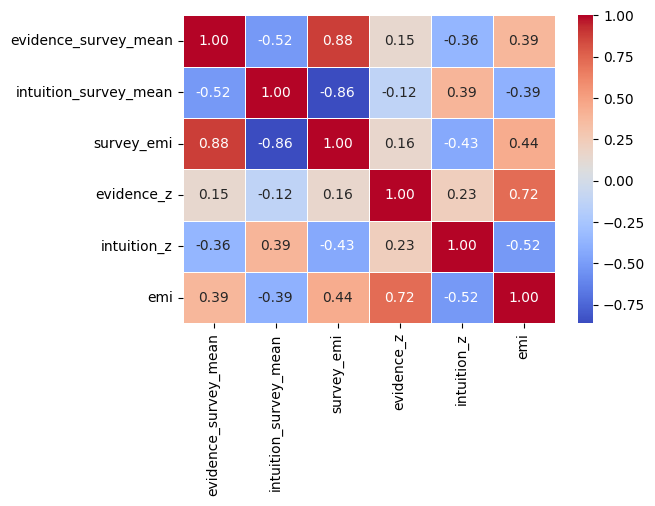

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute the correlation matrix
correlation_matrix = df[["evidence_survey_mean", "intuition_survey_mean", "survey_emi", 
                         "evidence_z", "intuition_z", "emi"]].corr()

# Create a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
#plt.title("Correlation Heatmap")
plt.savefig("survey_corr.png")
plt.show()


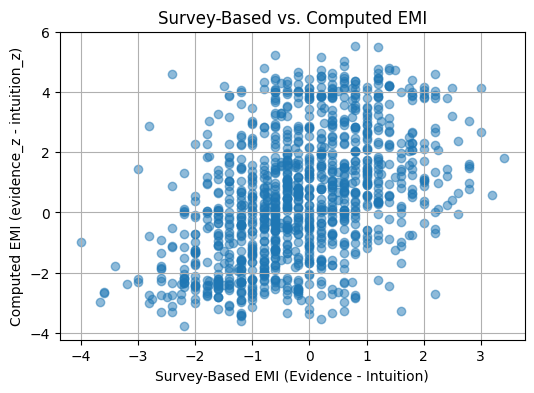

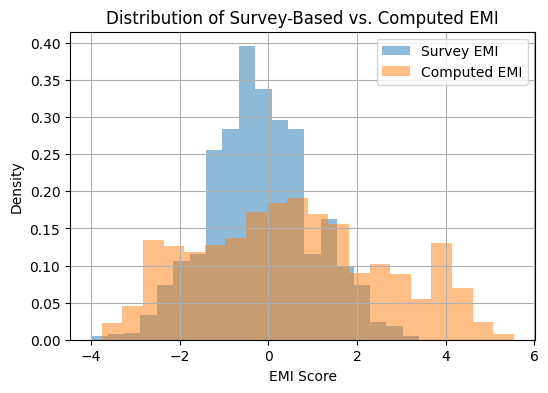

In [19]:
# Scatter plot of survey-based EMI vs. computed EMI
plt.figure(figsize=(6, 4))
plt.scatter(df["survey_emi"], df["emi"], alpha=0.5)
plt.xlabel("Survey-Based EMI (Evidence - Intuition)")
plt.ylabel("Computed EMI (evidence_z - intuition_z)")
plt.title("Survey-Based vs. Computed EMI")
plt.grid(True)
plt.show()

# Histograms of Survey-Based EMI vs. Computed EMI
plt.figure(figsize=(6, 4))
plt.hist(df["survey_emi"].dropna(), bins=20, alpha=0.5, label="Survey EMI", density=True)
plt.hist(df["emi"].dropna(), bins=20, alpha=0.5, label="Computed EMI", density=True)
plt.xlabel("EMI Score")
plt.ylabel("Density")
plt.title("Distribution of Survey-Based vs. Computed EMI")
plt.legend()
plt.grid(True)
plt.show()


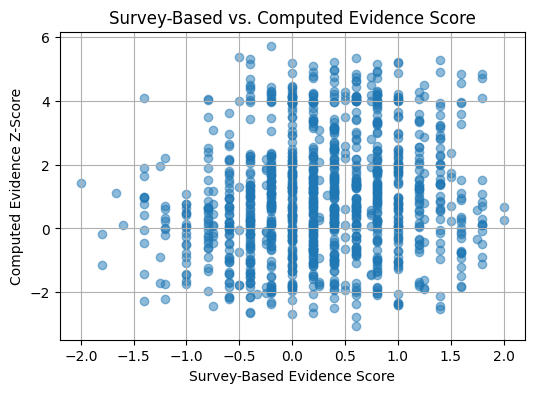

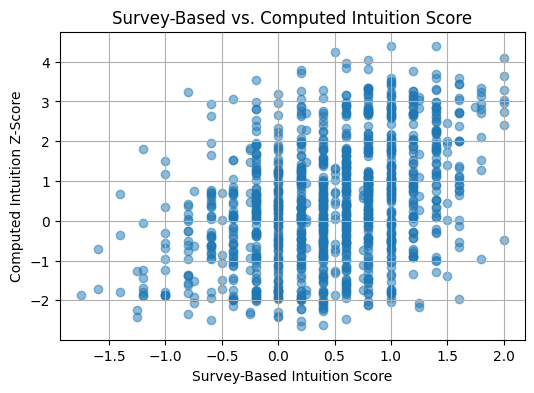

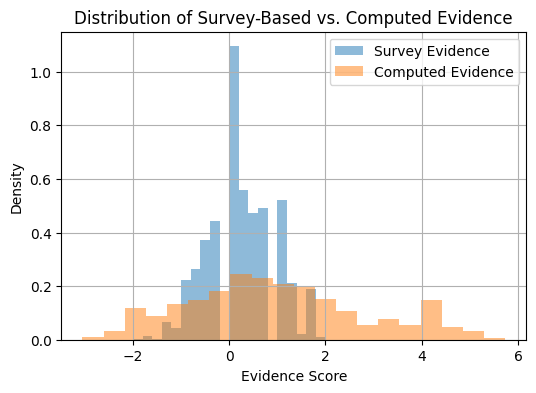

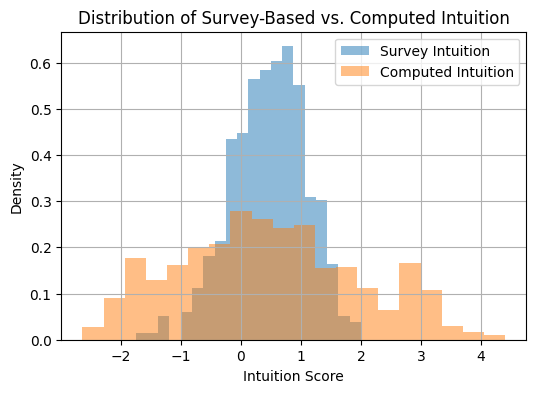

In [20]:
# Scatter plot of survey-based vs. computed Evidence scores
plt.figure(figsize=(6, 4))
plt.scatter(df["evidence_survey_mean"], df["evidence_z"], alpha=0.5)
plt.xlabel("Survey-Based Evidence Score")
plt.ylabel("Computed Evidence Z-Score")
plt.title("Survey-Based vs. Computed Evidence Score")
plt.grid(True)
plt.show()

# Scatter plot of survey-based vs. computed Intuition scores
plt.figure(figsize=(6, 4))
plt.scatter(df["intuition_survey_mean"], df["intuition_z"], alpha=0.5)
plt.xlabel("Survey-Based Intuition Score")
plt.ylabel("Computed Intuition Z-Score")
plt.title("Survey-Based vs. Computed Intuition Score")
plt.grid(True)
plt.show()

# Histograms of Survey-Based Evidence vs. Computed Evidence
plt.figure(figsize=(6, 4))
plt.hist(df["evidence_survey_mean"].dropna(), bins=20, alpha=0.5, label="Survey Evidence", density=True)
plt.hist(df["evidence_z"].dropna(), bins=20, alpha=0.5, label="Computed Evidence", density=True)
plt.xlabel("Evidence Score")
plt.ylabel("Density")
plt.title("Distribution of Survey-Based vs. Computed Evidence")
plt.legend()
plt.grid(True)
plt.show()

# Histograms of Survey-Based Intuition vs. Computed Intuition
plt.figure(figsize=(6, 4))
plt.hist(df["intuition_survey_mean"].dropna(), bins=20, alpha=0.5, label="Survey Intuition", density=True)
plt.hist(df["intuition_z"].dropna(), bins=20, alpha=0.5, label="Computed Intuition", density=True)
plt.xlabel("Intuition Score")
plt.ylabel("Density")
plt.title("Distribution of Survey-Based vs. Computed Intuition")
plt.legend()
plt.grid(True)
plt.show()


In [21]:
import scipy.stats
import statsmodels.api as sm

# Regression analysis: Predict survey_emi using evidence_z and intuition_z
X = df[["evidence_z", "intuition_z"]].dropna()
y = df.loc[X.index, "survey_emi"]

X = sm.add_constant(X)  # Add intercept
model = sm.OLS(y, X).fit()

# Kolmogorov-Smirnov Test for distribution similarity
ks_stat, ks_pvalue = scipy.stats.ks_2samp(df["survey_emi"].dropna(), df["emi"].dropna())

# Display regression results
model_summary = model.summary()
model_summary, (ks_stat, ks_pvalue)

(<class 'statsmodels.iolib.summary.Summary'>
 """
                             OLS Regression Results                            
 Dep. Variable:             survey_emi   R-squared:                       0.253
 Model:                            OLS   Adj. R-squared:                  0.252
 Method:                 Least Squares   F-statistic:                     192.8
 Date:                Tue, 11 Mar 2025   Prob (F-statistic):           7.77e-73
 Time:                        13:50:45   Log-Likelihood:                -1640.7
 No. Observations:                1142   AIC:                             3287.
 Df Residuals:                    1139   BIC:                             3303.
 Df Model:                           2                                         
 Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
 --------------------------------------------------------------------

In [22]:
print(model_summary.as_latex())

\begin{center}
\begin{tabular}{lclc}
\toprule
\textbf{Dep. Variable:}    &   survey\_emi    & \textbf{  R-squared:         } &     0.253   \\
\textbf{Model:}            &       OLS        & \textbf{  Adj. R-squared:    } &     0.252   \\
\textbf{Method:}           &  Least Squares   & \textbf{  F-statistic:       } &     192.8   \\
\textbf{Date:}             & Tue, 11 Mar 2025 & \textbf{  Prob (F-statistic):} &  7.77e-73   \\
\textbf{Time:}             &     13:50:45     & \textbf{  Log-Likelihood:    } &   -1640.7   \\
\textbf{No. Observations:} &        1142      & \textbf{  AIC:               } &     3287.   \\
\textbf{Df Residuals:}     &        1139      & \textbf{  BIC:               } &     3303.   \\
\textbf{Df Model:}         &           2      & \textbf{                     } &             \\
\textbf{Covariance Type:}  &    nonrobust     & \textbf{                     } &             \\
\bottomrule
\end{tabular}
\begin{tabular}{lcccccc}
                      & \textbf{coef} &

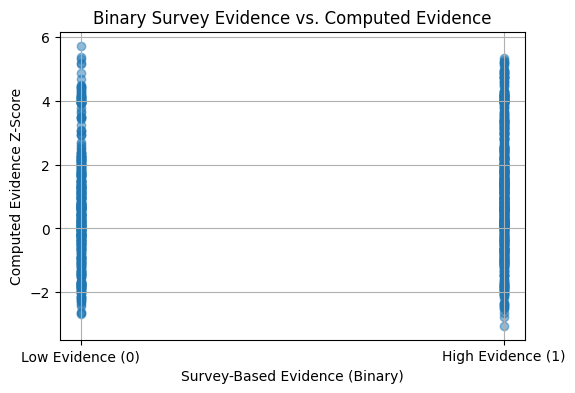

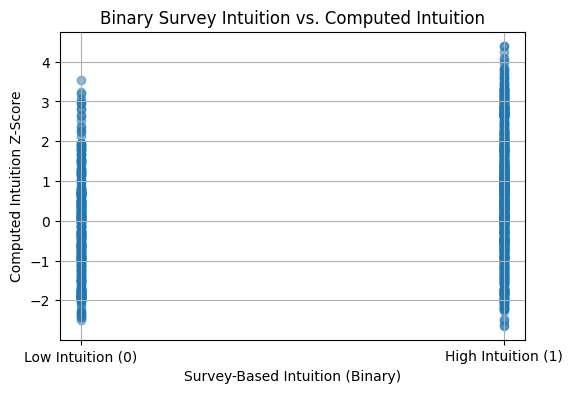

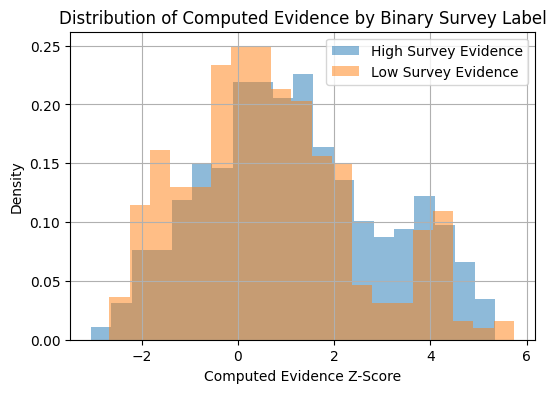

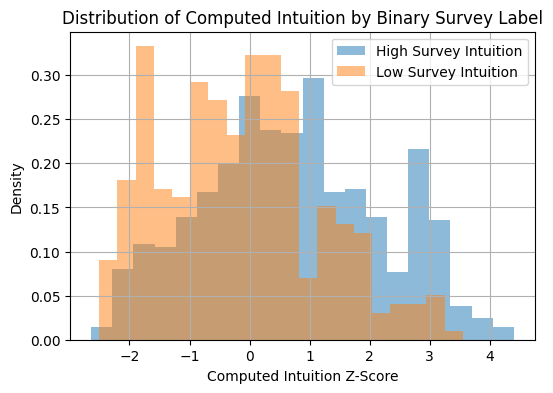

In [23]:
df_survey = df
# Binarize survey responses: Assign 1 for positive scores, 0 for negative or zero
df_survey["evidence_survey_bin"] = (df_survey["evidence_survey_mean"] > 0).astype(int)
df_survey["intuition_survey_bin"] = (df_survey["intuition_survey_mean"] > 0).astype(int)

# Scatter plot of survey-based vs. computed Evidence with binary labels
plt.figure(figsize=(6, 4))
plt.scatter(df_survey["evidence_survey_bin"], df_survey["evidence_z"], alpha=0.5)
plt.xlabel("Survey-Based Evidence (Binary)")
plt.ylabel("Computed Evidence Z-Score")
plt.title("Binary Survey Evidence vs. Computed Evidence")
plt.xticks([0, 1], labels=["Low Evidence (0)", "High Evidence (1)"])
plt.grid(True)
plt.show()

# Scatter plot of survey-based vs. computed Intuition with binary labels
plt.figure(figsize=(6, 4))
plt.scatter(df_survey["intuition_survey_bin"], df_survey["intuition_z"], alpha=0.5)
plt.xlabel("Survey-Based Intuition (Binary)")
plt.ylabel("Computed Intuition Z-Score")
plt.title("Binary Survey Intuition vs. Computed Intuition")
plt.xticks([0, 1], labels=["Low Intuition (0)", "High Intuition (1)"])
plt.grid(True)
plt.show()

# Histograms for binary Evidence vs. Computed Evidence
plt.figure(figsize=(6, 4))
plt.hist(df_survey[df_survey["evidence_survey_bin"] == 1]["evidence_z"].dropna(), bins=20, alpha=0.5, label="High Survey Evidence", density=True)
plt.hist(df_survey[df_survey["evidence_survey_bin"] == 0]["evidence_z"].dropna(), bins=20, alpha=0.5, label="Low Survey Evidence", density=True)
plt.xlabel("Computed Evidence Z-Score")
plt.ylabel("Density")
plt.title("Distribution of Computed Evidence by Binary Survey Label")
plt.legend()
plt.grid(True)
plt.show()

# Histograms for binary Intuition vs. Computed Intuition
plt.figure(figsize=(6, 4))
plt.hist(df_survey[df_survey["intuition_survey_bin"] == 1]["intuition_z"].dropna(), bins=20, alpha=0.5, label="High Survey Intuition", density=True)
plt.hist(df_survey[df_survey["intuition_survey_bin"] == 0]["intuition_z"].dropna(), bins=20, alpha=0.5, label="Low Survey Intuition", density=True)
plt.xlabel("Computed Intuition Z-Score")
plt.ylabel("Density")
plt.title("Distribution of Computed Intuition by Binary Survey Label")
plt.legend()
plt.grid(True)
plt.show()


In [24]:
df.keys()

Index(['id', 'evidence survey', 'intuition survey', 'N', 'original_text',
       'text', 'emi_bin', 'intuition_bin', 'evidence_bin', 'decade', 'year',
       'begin', 'end', 'date', 'session', 'electoralTerm', 'firstName',
       'lastName', 'politicianId', 'factionId', 'documentUrl', 'positionShort',
       'positionLong', 'length', 'chunk_length', 'evidence_score',
       'intuition_score', 'chunk_length_bin', 'evidence_mean', 'evidence_adj',
       'intuition_mean', 'intuition_adj', 'evidence_z', 'intuition_z', 'emi',
       'evidence_agreement', 'intuition_agreement', 'evidence_transformed',
       'intuition_transformed', 'evidence_agreement_transformed',
       'intuition_agreement_transformed', 'human_evidence_label',
       'human_intuition_label', 'evidence_annotations',
       'intuition_annotations', 'evidence_survey_mean',
       'intuition_survey_mean', 'survey_emi', 'evidence_survey_bin',
       'intuition_survey_bin'],
      dtype='object')

In [25]:
# Create human EMI label: 1 if survey EMI is > 0, else 0
df["human_emi_label"] = (df["survey_emi"] > 0).astype(int)

# Display a sample of the new column
df[["survey_emi", "human_emi_label"]].head()


,survey_emi,human_emi_label
1,-0.4,0
2,-0.4,0
3,-1.2,0
4,-2.6,0
5,-2.0,0


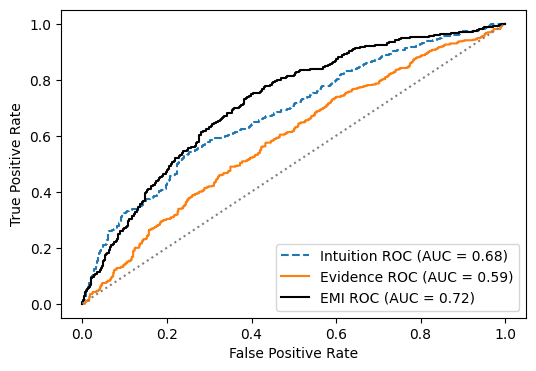

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Assuming df contains 'human_evidence_label', 'human_intuition_label', 'evidence_z', and 'intuition_z'
# Compute ROC for intuition_z as predictor
fpr_intuition, tpr_intuition, _ = roc_curve(df["human_intuition_label"], df["intuition_z"])
roc_auc_intuition = auc(fpr_intuition, tpr_intuition)

# Compute ROC for evidence_z as predictor
fpr_evidence, tpr_evidence, _ = roc_curve(df["human_evidence_label"], df["evidence_z"])
roc_auc_evidence = auc(fpr_evidence, tpr_evidence)

fpr_emi, tpr_emi, thresholds_emi = roc_curve(df["human_emi_label"], df["emi"])
roc_auc_emi = auc(fpr_emi, tpr_emi)



# Plot ROC curves
plt.figure(figsize=(6, 4))
plt.plot(fpr_intuition, tpr_intuition, label=f'Intuition ROC (AUC = {roc_auc_intuition:.2f})', linestyle='--')
plt.plot(fpr_evidence, tpr_evidence, label=f'Evidence ROC (AUC = {roc_auc_evidence:.2f})', linestyle='-')
plt.plot(fpr_emi, tpr_emi, label=f'EMI ROC (AUC = {roc_auc_emi:.2f})', linestyle='-',color = "black")

# Plot diagonal line for reference
plt.plot([0, 1], [0, 1], color="grey", linestyle=":")

# Labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
#plt.title("ROC Curves for Evidence and Intuition Scores")
plt.legend(loc="lower right")
plt.savefig("roc1.png")
# Show plot
plt.show()


In [27]:
# Compute ROC for intuition_z predicting human_intuition_label
fpr_intuition, tpr_intuition, thresholds_intuition = roc_curve(df["human_intuition_label"], df["intuition_z"])
youden_j_intuition = tpr_intuition - fpr_intuition
optimal_idx_intuition = np.argmax(youden_j_intuition)
optimal_threshold_intuition = thresholds_intuition[optimal_idx_intuition]

# Compute ROC for evidence_z predicting human_evidence_label
fpr_evidence, tpr_evidence, thresholds_evidence = roc_curve(df["human_evidence_label"], df["evidence_z"])
youden_j_evidence = tpr_evidence - fpr_evidence
optimal_idx_evidence = np.argmax(youden_j_evidence)
optimal_threshold_evidence = thresholds_evidence[optimal_idx_evidence]

# Output results
optimal_threshold_intuition, optimal_threshold_evidence

(0.73244333, 0.7803264)

In [28]:
# Apply thresholds to classify intuition_z and evidence_z
df["predicted_intuition_label"] = (df["intuition_z"] >= optimal_threshold_intuition).astype(int)
df["predicted_evidence_label"] = (df["evidence_z"] >= optimal_threshold_evidence).astype(int)

# Display a sample of the new labels
df[["intuition_z", "predicted_intuition_label", "evidence_z", "predicted_evidence_label"]].head()


,intuition_z,predicted_intuition_label,evidence_z,predicted_evidence_label
1,1.780287,1,-0.707661,0
2,1.088502,1,2.176502,1
3,1.725261,1,5.318909,1
4,2.012872,1,0.655849,0
5,2.238965,1,1.536199,1


In [29]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Evaluate intuition classification
accuracy_intuition = accuracy_score(df["human_intuition_label"], df["predicted_intuition_label"])
conf_matrix_intuition = confusion_matrix(df["human_intuition_label"], df["predicted_intuition_label"])
report_intuition = classification_report(df["human_intuition_label"], df["predicted_intuition_label"])

# Evaluate evidence classification
accuracy_evidence = accuracy_score(df["human_evidence_label"], df["predicted_evidence_label"])
conf_matrix_evidence = confusion_matrix(df["human_evidence_label"], df["predicted_evidence_label"])
report_evidence = classification_report(df["human_evidence_label"], df["predicted_evidence_label"])

print(f"Intuition Classification Accuracy: {accuracy_intuition:.2f}")
print("Confusion Matrix (Intuition):\n", conf_matrix_intuition)
print("Classification Report (Intuition):\n", report_intuition)

print(f"Evidence Classification Accuracy: {accuracy_evidence:.2f}")
print("Confusion Matrix (Evidence):\n", conf_matrix_evidence)
print("Classification Report (Evidence):\n", report_evidence)


Intuition Classification Accuracy: 0.63
Confusion Matrix (Intuition):
 [[376 127]
 [293 346]]
Classification Report (Intuition):
               precision    recall  f1-score   support

           0       0.56      0.75      0.64       503
           1       0.73      0.54      0.62       639

    accuracy                           0.63      1142
   macro avg       0.65      0.64      0.63      1142
weighted avg       0.66      0.63      0.63      1142

Evidence Classification Accuracy: 0.57
Confusion Matrix (Evidence):
 [[349 268]
 [223 302]]
Classification Report (Evidence):
               precision    recall  f1-score   support

           0       0.61      0.57      0.59       617
           1       0.53      0.58      0.55       525

    accuracy                           0.57      1142
   macro avg       0.57      0.57      0.57      1142
weighted avg       0.57      0.57      0.57      1142



In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Train a logistic regression model
clf = LogisticRegression()
clf.fit(df[["intuition_z", "evidence_z"]], df["human_intuition_label"])

# Predict probabilities and compute AUC
pred_probs = clf.predict_proba(df[["intuition_z", "evidence_z"]])[:, 1]
auc_score = roc_auc_score(df["human_intuition_label"], pred_probs)

print(f"Improved AUC with Logistic Regression: {auc_score:.2f}")

Improved AUC with Logistic Regression: 0.71


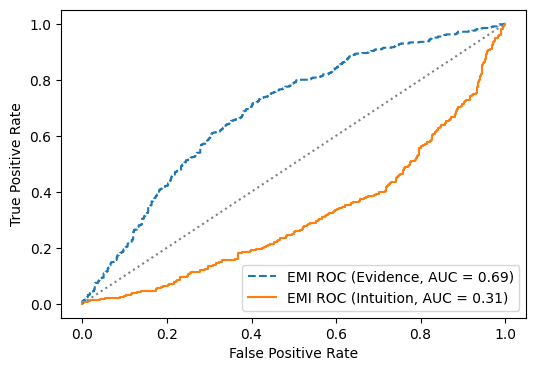

In [31]:
# Compute ROC for EMI score as predictor for both ground truths
df["emi_score"] = df["evidence_z"] - df["intuition_z"]

# Compute ROC for EMI score predicting human_evidence_label
fpr_emi_evidence, tpr_emi_evidence, _ = roc_curve(df["human_evidence_label"], df["emi_score"])
roc_auc_emi_evidence = auc(fpr_emi_evidence, tpr_emi_evidence)

# Compute ROC for EMI score predicting human_intuition_label
fpr_emi_intuition, tpr_emi_intuition, _ = roc_curve(df["human_intuition_label"], df["emi_score"])
roc_auc_emi_intuition = auc(fpr_emi_intuition, tpr_emi_intuition)

# Plot ROC curves
plt.figure(figsize=(6, 4))
plt.plot(fpr_emi_evidence, tpr_emi_evidence, label=f'EMI ROC (Evidence, AUC = {roc_auc_emi_evidence:.2f})', linestyle='--')
plt.plot(fpr_emi_intuition, tpr_emi_intuition, label=f'EMI ROC (Intuition, AUC = {roc_auc_emi_intuition:.2f})', linestyle='-')

# Plot diagonal line for reference
plt.plot([0, 1], [0, 1], color="grey", linestyle=":")

# Labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
#plt.title("ROC Curves for EMI Score on Evidence and Intuition Labels")
plt.legend(loc="lower right")

# Show plot
plt.show()


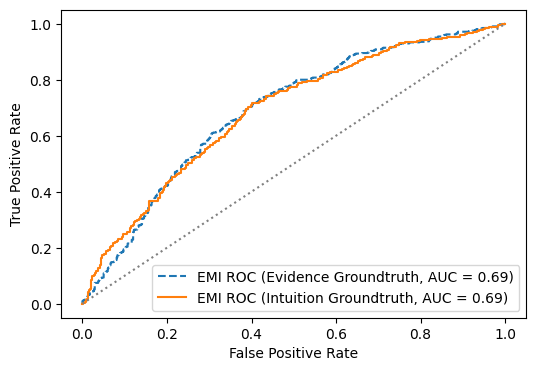

In [32]:
# Ensure intuition label is inverted (0 = intuition, 1 = not intuition) for EMI alignment
df["human_intuition_label_inverted"] = 1 - df["human_intuition_label"]

# Compute ROC for EMI predicting human_evidence_label
fpr_emi_evidence, tpr_emi_evidence, _ = roc_curve(df["human_evidence_label"], df["emi_score"])
roc_auc_emi_evidence = auc(fpr_emi_evidence, tpr_emi_evidence)

# Compute ROC for EMI predicting human_intuition_label (inverted for consistency with EMI definition)
fpr_emi_intuition, tpr_emi_intuition, _ = roc_curve(df["human_intuition_label_inverted"], df["emi_score"])
roc_auc_emi_intuition = auc(fpr_emi_intuition, tpr_emi_intuition)

# Plot ROC curves
plt.figure(figsize=(6, 4))
plt.plot(fpr_emi_evidence, tpr_emi_evidence, label=f'EMI ROC (Evidence Groundtruth, AUC = {roc_auc_emi_evidence:.2f})', linestyle='--')
plt.plot(fpr_emi_intuition, tpr_emi_intuition, label=f'EMI ROC (Intuition Groundtruth, AUC = {roc_auc_emi_intuition:.2f})', linestyle='-')


# Plot diagonal line for reference
plt.plot([0, 1], [0, 1], color="grey", linestyle=":")

# Labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
#plt.title("ROC Curves for EMI Score on Evidence and Intuition Labels")
plt.legend(loc="lower right")
plt.savefig("roc2.png")

# Show plot
plt.show()


In [33]:
df.to_csv("emi_survey.csv", index = False)

In [34]:
newest_decades = df["decade"].unique()
newest_decades.sort()
newest_decades = newest_decades[-(len(newest_decades) // 2):]  # Select the newest 50%

# Filter the DataFrame to keep only the newest 50% of decades
df = df[df["decade"].isin(newest_decades)]

In [35]:
df

,id,evidence survey,intuition survey,N,original_text,text,emi_bin,intuition_bin,evidence_bin,decade,...,evidence_survey_mean,intuition_survey_mean,survey_emi,evidence_survey_bin,intuition_survey_bin,human_emi_label,predicted_intuition_label,predicted_evidence_label,emi_score,human_intuition_label_inverted
1,10001,"[1.0, -2.0, -2.0, 2.0, 2.0]","[-1.0, 2.0, 2.0, 2.0, -2.0]",5,"Ich lehne es ab, mich in diesem Hohen Hause au...",lehne Hohen Hause Niveau begeben Kabarett übli...,"(-5.186191999999999, -2.1966578749999996]","(0.46014310000000025, 2.6364639000000003]","(-1.70590185, 1.1031212999999997]",1950.0,...,0.20,0.60,-0.4,1,1,0,1,0,-2.487948,0
2,1004280,"[1.0, 1.0, 1.0, 1.0, -1.0]","[-1.0, 0.0, 2.0, 2.0, 2.0]",5,"Frau Kollegin, vielen Dank, dass Sie noch einm...",Kollegin vielen Dank darauf hinweisen deutlich...,"(0.79287625, 3.7824103750000004]","(0.46014310000000025, 2.6364639000000003]","(1.1031212999999997, 3.9121444499999996]",2010.0,...,0.60,1.00,-0.4,1,1,0,1,1,1.088000,0
3,1005062,"[1.0, -2.0, -1.0, 2.0, -2.0]","[-2.0, 2.0, 1.0, 1.0, 2.0]",5,"Vielen Dank, Frau Kollegin, dass ich diese Zwi...",Vielen Dank Kollegin Zwischenfrage stellen dar...,"(0.79287625, 3.7824103750000004]","(0.46014310000000025, 2.6364639000000003]","(3.9121444499999996, 6.721167599999999]",2010.0,...,-0.40,0.80,-1.2,0,1,0,1,1,3.593648,0
4,1006590,"[1.0, -2.0, -1.0, -1.0, -2.0]","[2.0, 2.0, 1.0, 1.0, 2.0]",5,Da die Staatsanwaltschaften und Gerichte diese...,Staatsanwaltschaften Gerichte Schlussfolgerung...,"(-2.1966578749999996, 0.79287625]","(0.46014310000000025, 2.6364639000000003]","(-1.70590185, 1.1031212999999997]",2010.0,...,-1.00,1.60,-2.6,0,1,0,1,0,-1.357023,0
5,1007107,"[0.0, -1.0, -1.0, -2.0, 1.0]","[1.0, 2.0, 2.0, 2.0, 0.0]",5,"Meine Damen und Herren, ich komme zum Ende. Ic...",komme Ende Bitte eigene Fraktion Lasst hervorr...,"(-2.1966578749999996, 0.79287625]","(0.46014310000000025, 2.6364639000000003]","(1.1031212999999997, 3.9121444499999996]",2010.0,...,-0.60,1.40,-2.0,0,1,0,1,1,-0.702766,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139,97649,"[1.0, 1.0, -1.0, -1.0, 1.0]","[-1.0, 2.0, 1.0, 1.0, 0.0]",5,"Herr Staatssekretär, darf ich aus Ihrer ersten...",Staatssekretär darf ersten Antwort entnehmen B...,"(0.79287625, 3.7824103750000004]","(-1.7161776999999998, 0.46014310000000025]","(1.1031212999999997, 3.9121444499999996]",1960.0,...,0.20,0.60,-0.4,1,1,0,0,1,0.899208,0
1140,97876,"[0.0, 1.0, 2.0, 0.0, 2.0]","[1.0, -2.0, -2.0, 0.0, 2.0]",5,"Herr Kollege Lohmar, würden Sie nicht doch an ...",Kollege Lohmar Hand zitierten Texte Verwaltung...,"(3.7824103750000004, 6.7719445]","(-1.7161776999999998, 0.46014310000000025]","(3.9121444499999996, 6.721167599999999]",1960.0,...,1.00,-0.20,1.2,1,0,1,0,1,4.384187,1
1141,9796,"[-2.0, 1.0, -1.0, 1.0, 1.0, -2.0, 1.0, -1.0, 1...","[2.0, -1.0, 1.0, 0.0, 1.0, 2.0, -1.0, 1.0, 0.0...",10,"Es gibt für Ihre Auffassung, Herr Mommer, nur ...",gibt Auffassung Mommer Erklärung nämlich Mitgl...,"(-2.1966578749999996, 0.79287625]","(2.6364639000000003, 4.8127847]","(1.1031212999999997, 3.9121444499999996]",1950.0,...,0.00,0.60,-0.6,0,1,0,1,1,-1.376097,0
1142,98182,"[0.0, -1.0, 0.0, 2.0, 2.0, 0.0, -1.0, 0.0, 2.0...","[0.0, 1.0, 0.0, 0.0, -2.0, 0.0, 1.0, 0.0, 0.0,...",10,"Herr Dr. Czaja, darf ich Sie bitten, dann auch...",Czaja darf bitten Abs interpretieren heißt Min...,"(0.79287625, 3.7824103750000004]","(-1.7161776999999998, 0.46014310000000025]","(-1.70590185, 1.1031212999999997]",1960.0,...,0.60,-0.20,0.8,1,0,1,0,0,1.998214,1


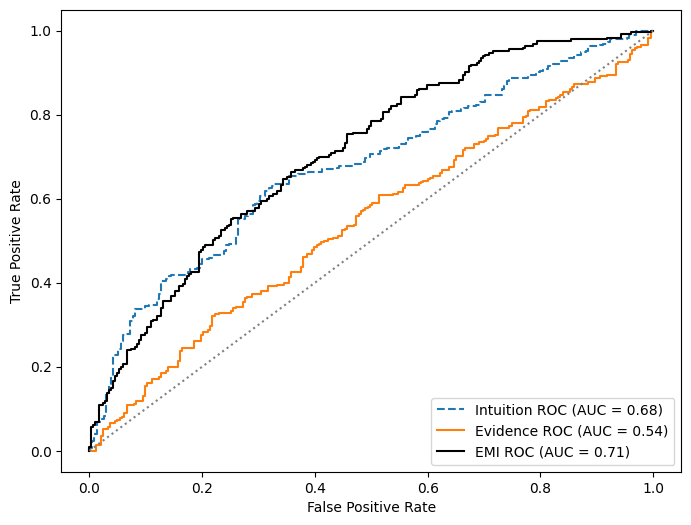

In [36]:
# Assuming df contains 'human_evidence_label', 'human_intuition_label', 'evidence_z', and 'intuition_z'
# Compute ROC for intuition_z as predictor
fpr_intuition, tpr_intuition, _ = roc_curve(df["human_intuition_label"], df["intuition_z"])
roc_auc_intuition = auc(fpr_intuition, tpr_intuition)

# Compute ROC for evidence_z as predictor
fpr_evidence, tpr_evidence, _ = roc_curve(df["human_evidence_label"], df["evidence_z"])
roc_auc_evidence = auc(fpr_evidence, tpr_evidence)

fpr_emi, tpr_emi, thresholds_emi = roc_curve(df["human_emi_label"], df["emi"])
roc_auc_emi = auc(fpr_emi, tpr_emi)



# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_intuition, tpr_intuition, label=f'Intuition ROC (AUC = {roc_auc_intuition:.2f})', linestyle='--')
plt.plot(fpr_evidence, tpr_evidence, label=f'Evidence ROC (AUC = {roc_auc_evidence:.2f})', linestyle='-')
plt.plot(fpr_emi, tpr_emi, label=f'EMI ROC (AUC = {roc_auc_emi:.2f})', linestyle='-',color = "black")

# Plot diagonal line for reference
plt.plot([0, 1], [0, 1], color="grey", linestyle=":")

# Labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
#plt.title("ROC Curves for Evidence and Intuition Scores")
plt.legend(loc="lower right")
plt.savefig("roc1_new.png")
# Show plot
plt.show()


<ipython-input-37-cd147c5718f9>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["human_intuition_label_inverted"] = 1 - df["human_intuition_label"]


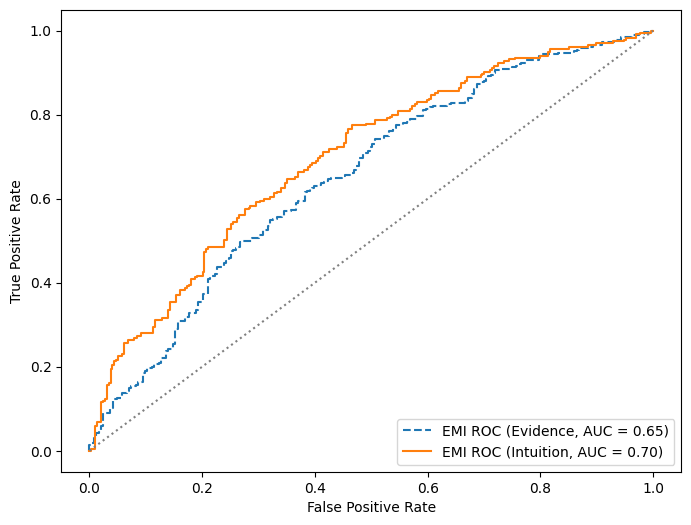

In [37]:
# Ensure intuition label is inverted (0 = intuition, 1 = not intuition) for EMI alignment
df["human_intuition_label_inverted"] = 1 - df["human_intuition_label"]

# Compute ROC for EMI predicting human_evidence_label
fpr_emi_evidence, tpr_emi_evidence, _ = roc_curve(df["human_evidence_label"], df["emi_score"])
roc_auc_emi_evidence = auc(fpr_emi_evidence, tpr_emi_evidence)

# Compute ROC for EMI predicting human_intuition_label (inverted for consistency with EMI definition)
fpr_emi_intuition, tpr_emi_intuition, _ = roc_curve(df["human_intuition_label_inverted"], df["emi_score"])
roc_auc_emi_intuition = auc(fpr_emi_intuition, tpr_emi_intuition)

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_emi_evidence, tpr_emi_evidence, label=f'EMI ROC (Evidence, AUC = {roc_auc_emi_evidence:.2f})', linestyle='--')
plt.plot(fpr_emi_intuition, tpr_emi_intuition, label=f'EMI ROC (Intuition, AUC = {roc_auc_emi_intuition:.2f})', linestyle='-')

# Plot diagonal line for reference
plt.plot([0, 1], [0, 1], color="grey", linestyle=":")

# Labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
#plt.title("ROC Curves for EMI Score on Evidence and Intuition Labels")
plt.legend(loc="lower right")
plt.savefig("roc2_new.png")

# Show plot
plt.show()